<a href="https://colab.research.google.com/github/GyeongHub/ESAA-OB/blob/main/week11_0516_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*0516(금) 11주차 과제*\
*딥러닝 파이토치 교과서 5장 합성곱 신경망1 - 01  p.166-179*

# 5.1 합성곱 신경망

합성곱 신경망: 이미지의 국소적 부분을 계산함으로써 시간과 자원을 절약하여 이미지의 세밀한 부분까지 분석할 수 있는 신경망

## 5.1.1 합성곱층의 필요성

합성곱층: 이미지를 펼쳐서 분석하면 데이터의 공간적 구조를 무시하게 되는데, 이를 방지하려고 도입됨.

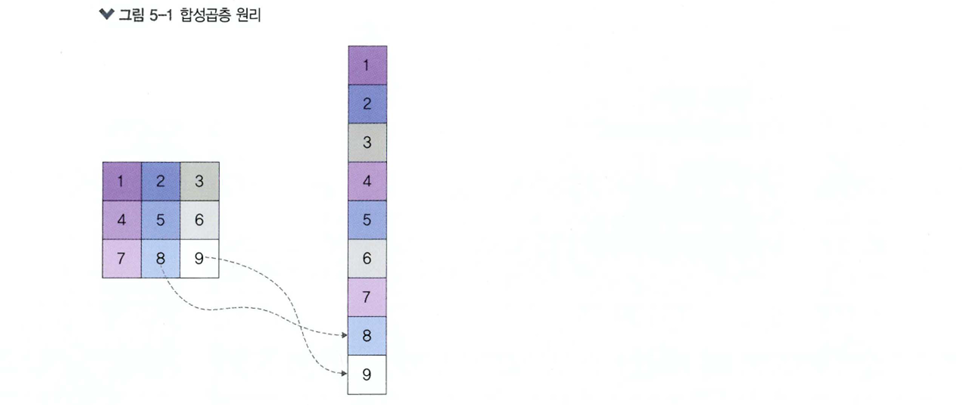

---
---

## 5.1.2 합성곱 신경망 구조

합성곱 신경망 구조: 컬러 이미지 같은 다차원 배열 처리에 특화됨.

- 합성곱 신경망의 계층
    1. 입력층
    2. 합성곱층
    3. 풀링층
    4. 완전연결층
    5. 출력층

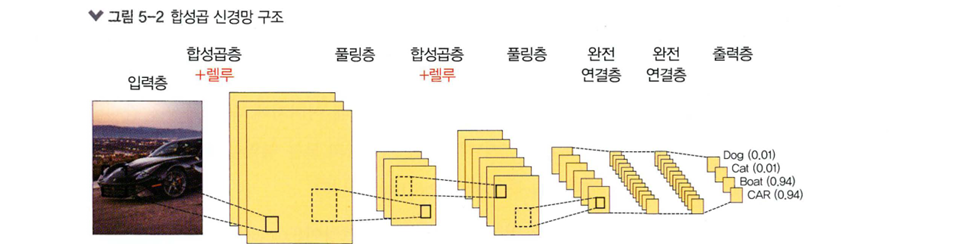

합성곱 신경망은 **합성곱층과 풀링층**을 거치면서 입력 이미지의 주요 특성 벡터를 추출함. 그 후 추출된 주요 특성 벡터들은 **완전연결층**을 거치면서 1차원 벡터로 변환되며, 마지막으로 **출력층**에서 활성화 함수인 소프트맥스(softmax) 함수를 사용하여 최종 결과가 출력됨.

---

**입력층**
- 입력 이미지 데이터가 최초로 거치게 되는 계층
- 이미지: 단순 1차원의 데이터가 아닌 높이, 너비, 채널의 값을 갖는 3차원 데이터
    - 채널은 이미지가 그레이스케일이면 1, 컬러면 3값을 가짐.

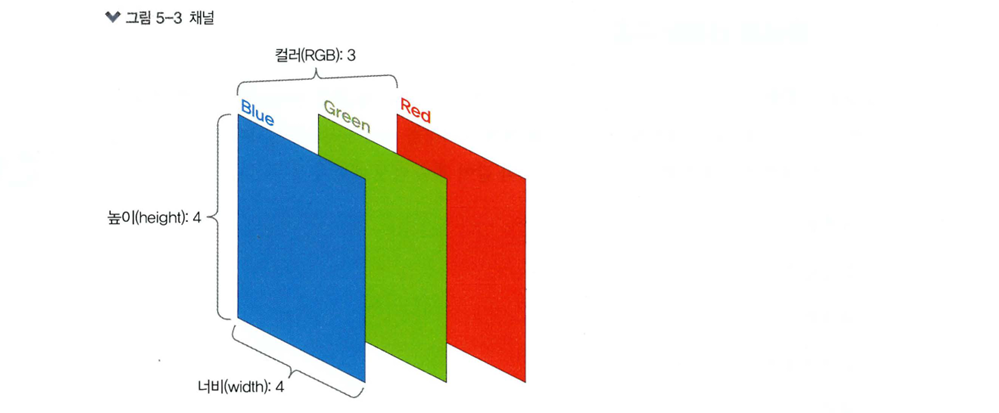

    예를 들어 위 그림은 높이 4, 너비 4, 채널 3(RGB)
    즉, 이미지 형태는 (4, 4, 3)

---

**합성곱층**

- 합성곱층: 입력 데이터에서 특성을 추출하는 역할

- 특성 추출 진행 과정
    - **커널(kernel)이나 필터**를 사용하여 입력 이미지에 대한 특성을 감지함.
    - 커널/필터는 이미지의 모든 영역을 훌으면서 특성을 추출하게 되는데, 이렇게 추출된 결과물이 **특성 맵(fearure map)**
    - 이때 커널은 3x3, 5x5 크기로 적용되는 것이 일반적이며, **스트라이드(stride)**라는 지정된 간격에 따라 순차적으로 이동함.

> 스트라이드가 1일 때 이동하는 과정 - 그레이스케일 이미지

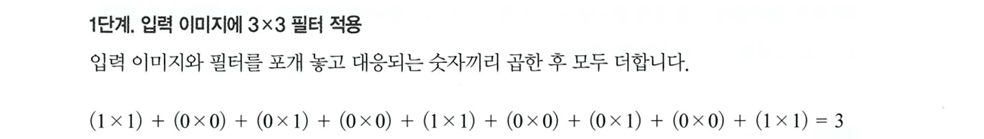

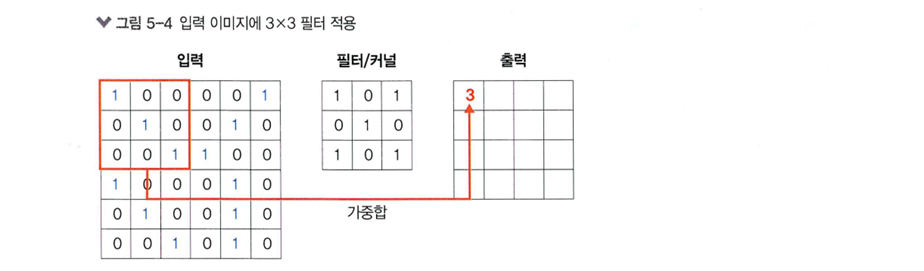

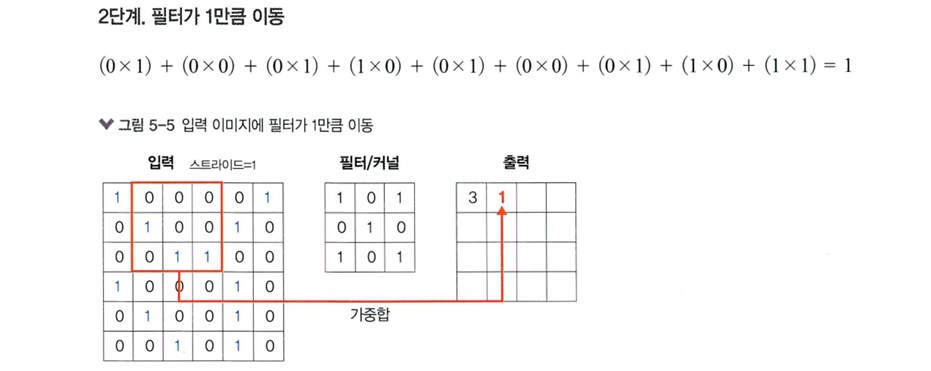

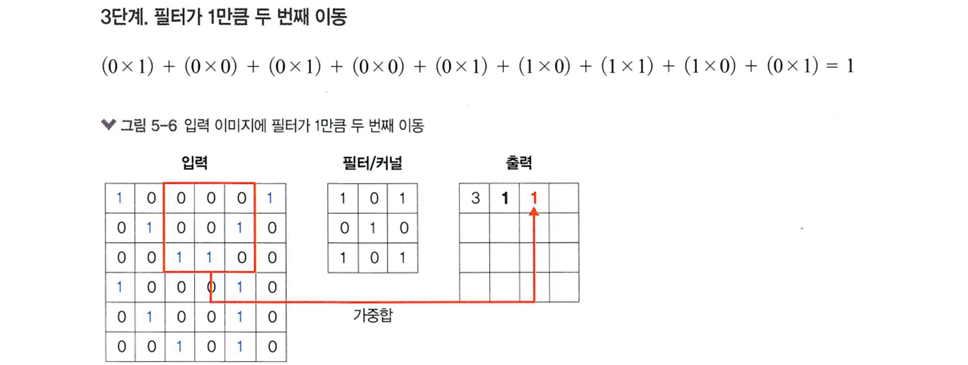

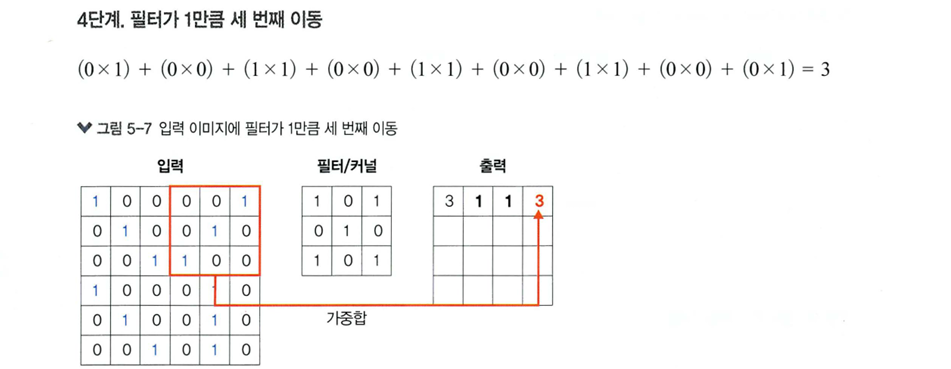

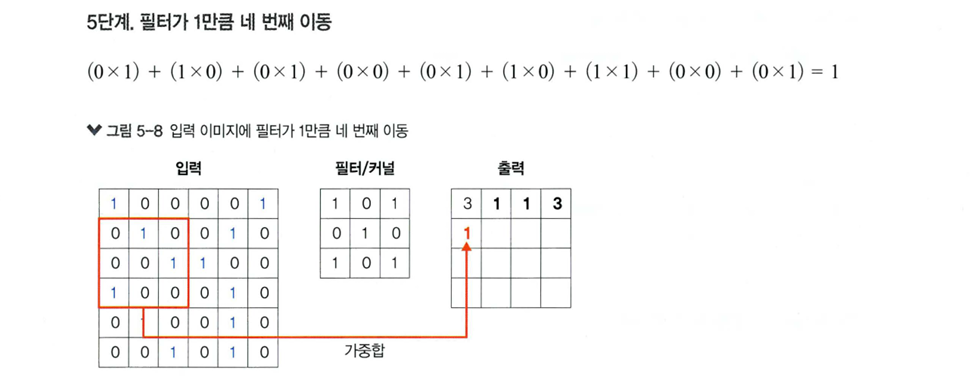

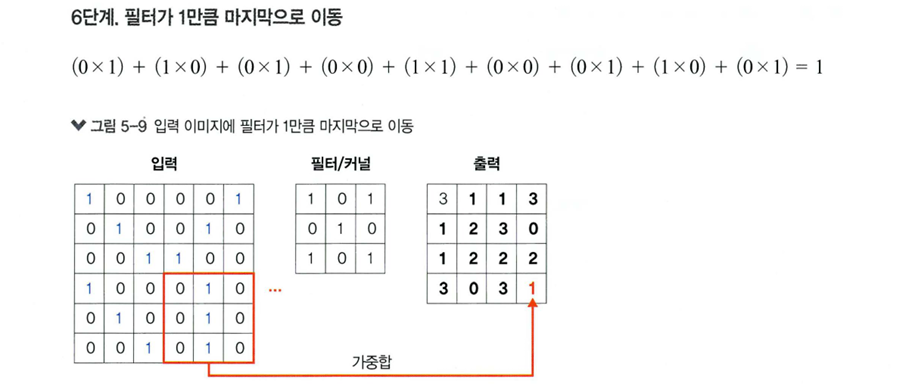

    커널과 스트라이드의 상호 작용으로 원본 (6, 6, 1) 크기가 (4, 4, 1) 크기의 특성 맵으로 줄어듦

> 컬러 이미지의 합성곱 (필터 1개)

그레이스케일 이미지와 구분되는 특징
    
1. 필터 채널 = 3
2. RGB 각각에 서로 다른 가중치로 합성곱을 적용한 후 결과를 더해 줌
 - 이때 필터 채널이 3이지만 필터 개수는 한 개라는 점에 주의해야 함!

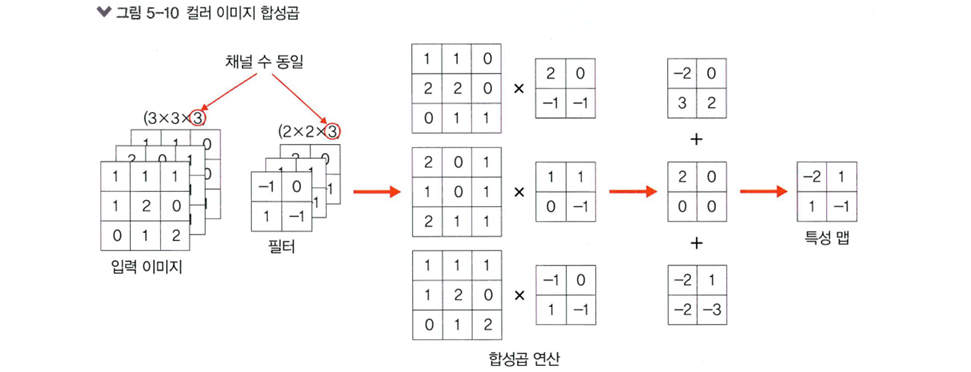

> 컬러 이미지의 합성곱 (필터 2개 이상)

필터 각각은 특성 추출 결과의 채널이 됨(각 계산은 앞서 진행했던 방법과 동일)

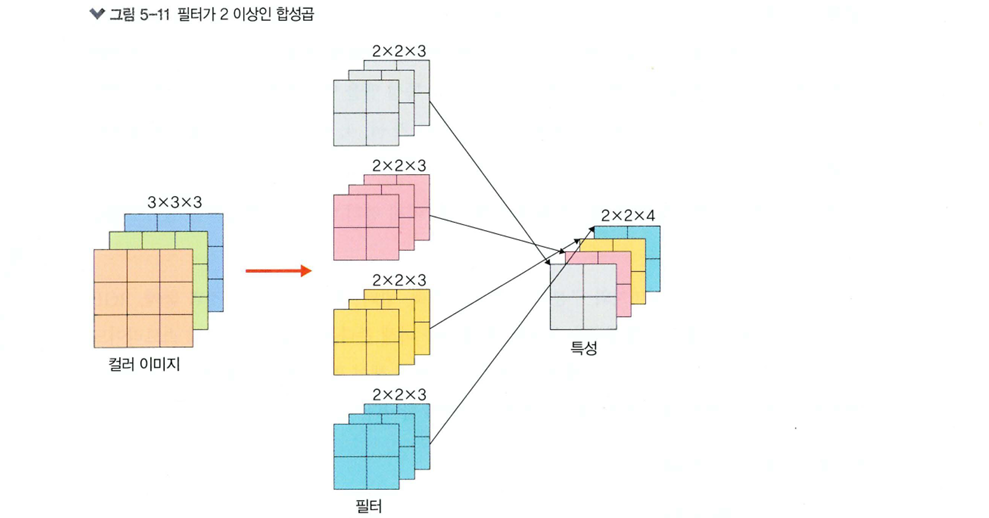

> 합성곱층 요약

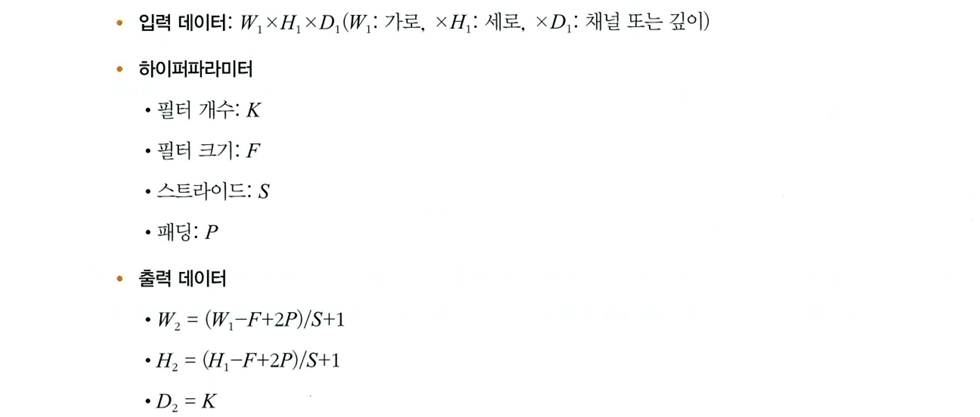

---

**풀링층**

합성곱층과 유사하게 특성 맵의 차원을 다운 샘플링하여 연산량을 감소시키고, 주요한 특성 벡터를 추출하여 학습을 효과적으로 할 수 있게 함.

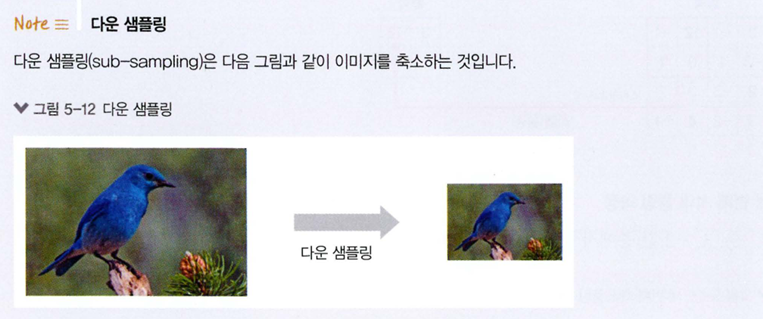

- 두 가지 풀링 연산
    - 최대 풀링: 대상 영역에서 최댓값을 추출
    - 평균 풀링: 대상 영역에서 평균을 반환

 대부분의 합성곱 신경망에서는 **최대 풀링**이 사용되는데, **평균 풀링**은 각 커널 값을 평균화시켜 중요한 가중치를 갖는 값의 특성이 희미해질 수 있기 때문임.

> 최대 풀링의 연산 과정

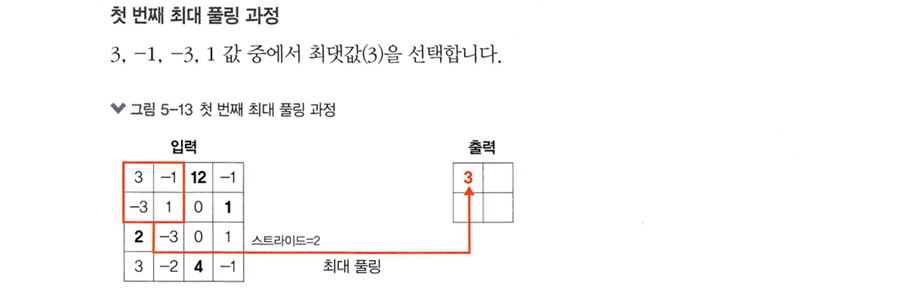

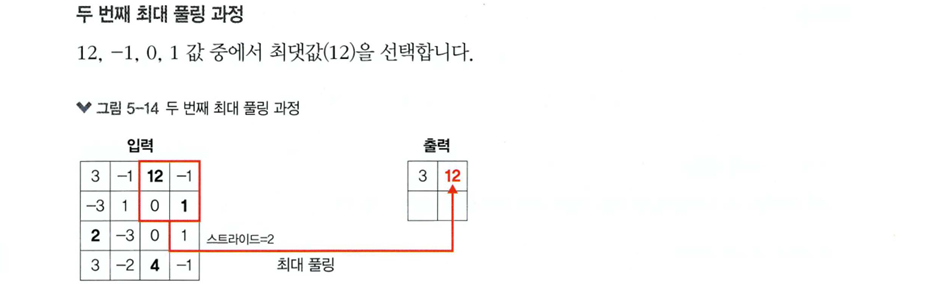

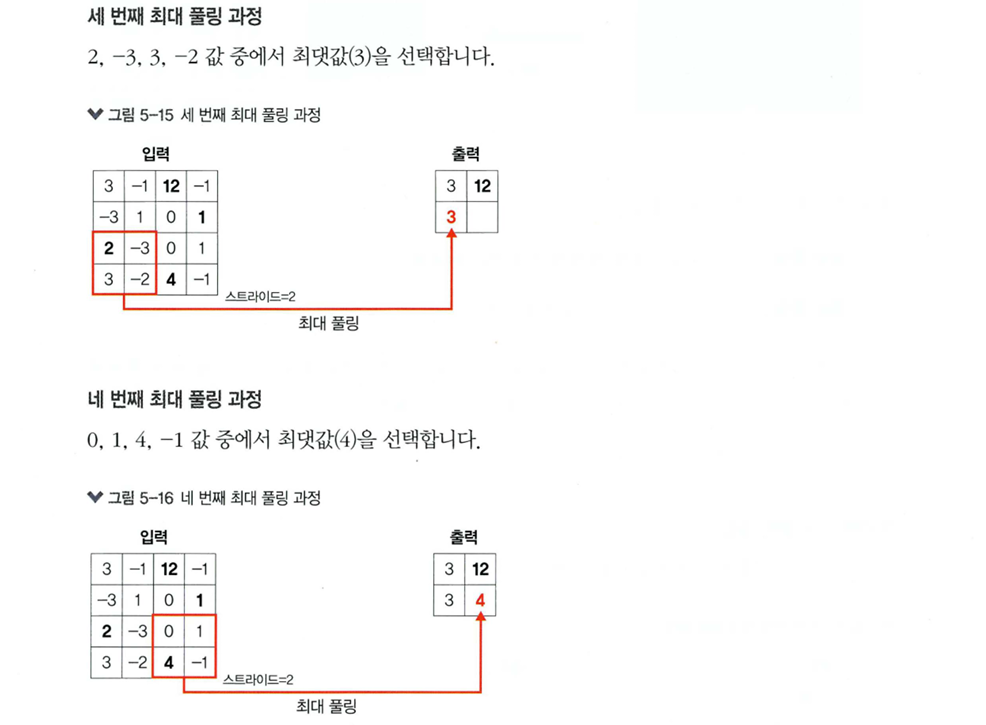

> 평균 풀링의 연산 과정

최대 풀링과 유사한 방식으로 진행하되 각 필터의 평균으로 계산함.

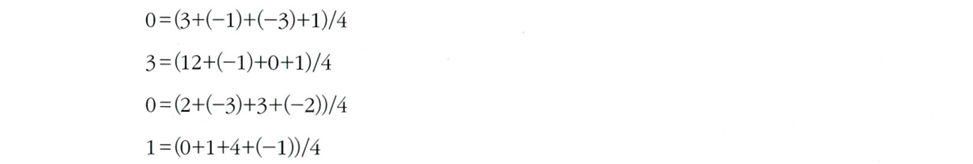

> 최대 풀링 결과 vs 평균 풀링 결과

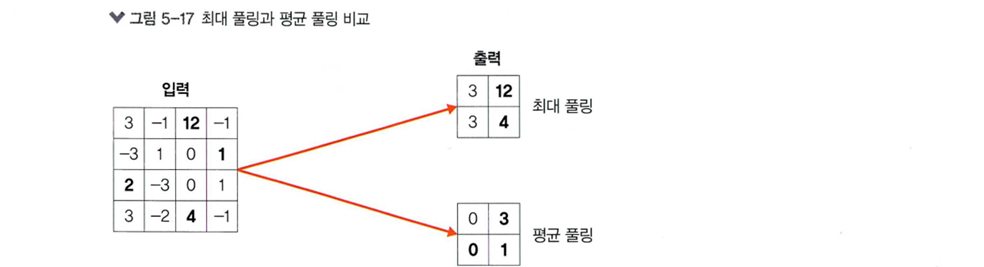

> 최대 풀링과 평균 풀링 요약 - 사용 파라미터 동일

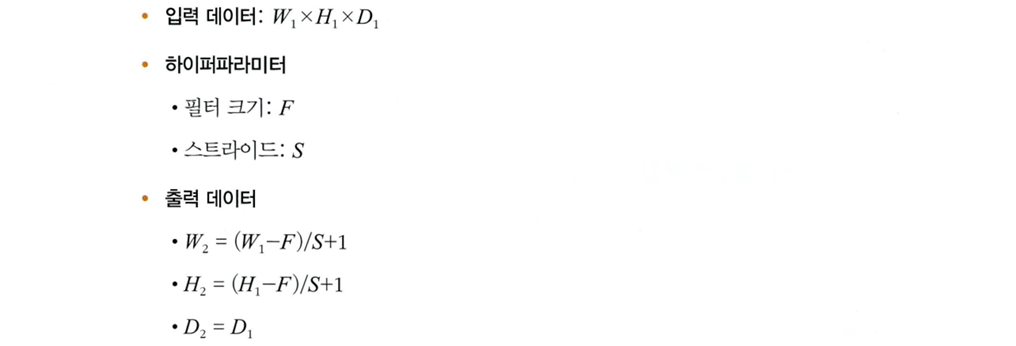

---

**완전연결층**

이미지를 3차원 벡터에서 1차원 벡터로 펼침(flatten)

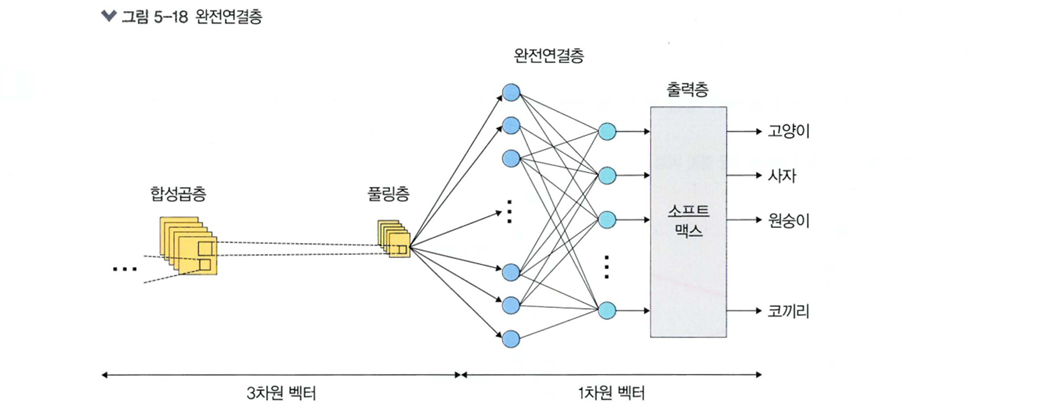

---

**출력층**

소프트맥스 함수를 사용하여 이미지가 각 레이블에 속할 0~1 사이의 확률 값이 출력되며, 이때 가장 높은 확률 값을 갖는 레이블이 최종 값으로 선정됨.

---
---

## 5.1.3 1D, 2D, 3D 합성곱

합성곱은 이동하는 방향의 수와 출력 형태에 따라 1D, 2D, 3D로 분류할 수 있음.

**1D 합성곱**

- 필터가 시간을 축으로 좌우로만 이동할 수 있는 합성곱.
- 따라서 입력(W)과 필터(k)에 대한 출력은 W가 되며, 출력 형태는 1D 행렬
- 예를 들어 입력이 [1, 1, 1, 1, 1]이고 필터가 [0.25, 0.5, 0.25]라면 출력은 [1, 1, 1]이 됨.

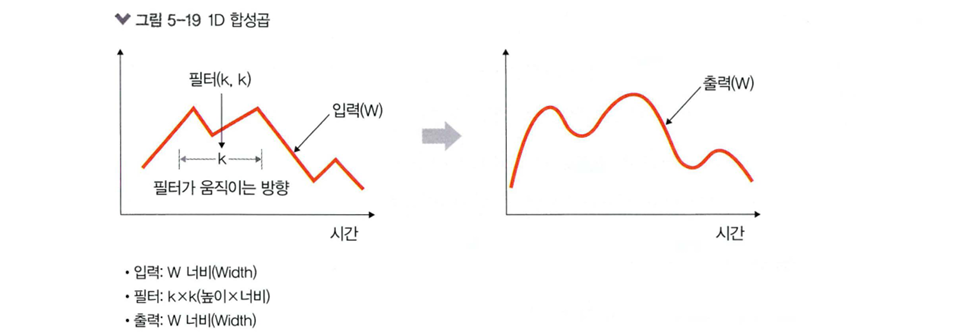

    즉, 위 그림과 같이 출력 형태는 1D의 배열이 되며, 그래프 곡선을 완화할 때 많이 사용됨

---

**2D 합성곱**

- 필터가 움직이는 방향이 두 개
- 입력(W, H)과 필터(k, k)에 대한 출력은 (W, H)가 되며 출력 형태는 2D 행렬.

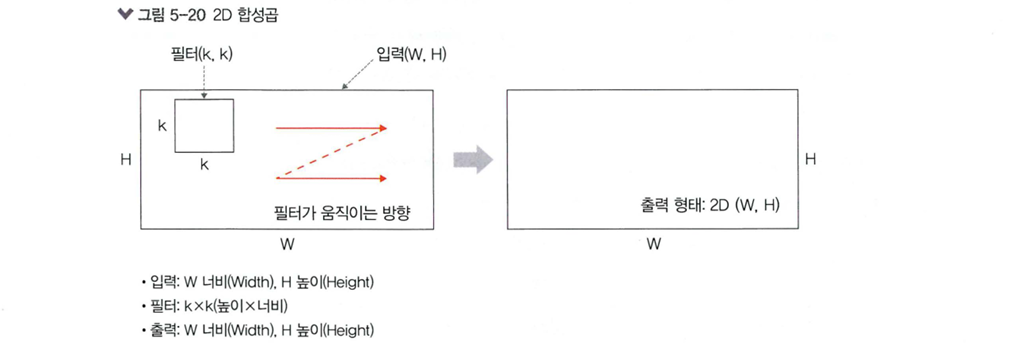

---

**3D 합성곱**

- 필터가 움직이는 방향이 세 개
- 입력(W, H, L)과 필터(k, k, d)에 대한 출력은 (W, H, L)이며, 출력 형태가 3D
- 이때 d < L을 유지하는 것이 중요함.

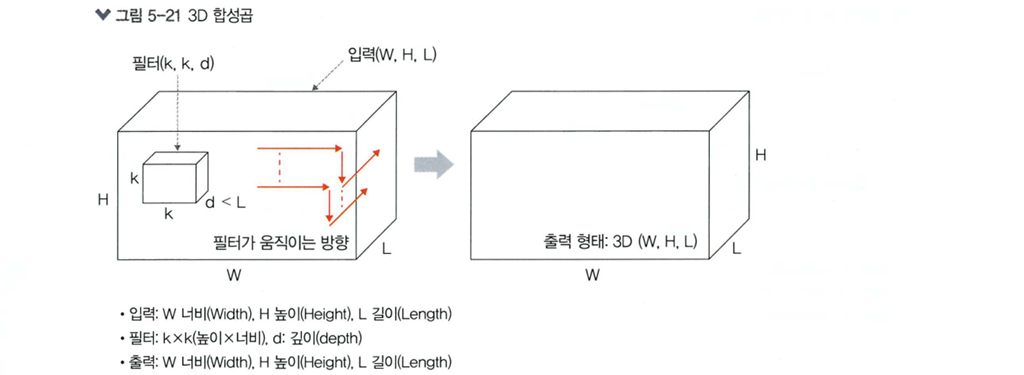

---

**3D 입력을 갖는 2D 합성곱**

- 입력이 3D 형태임에도 출력 형태가 2D 행렬을 취하는 것
    - 필터에 대한 길이(L)가 입력 채널의 길이(L)와 같아야 하기 때문.
- 필터가 움직이는 방향이 두 개
- 입력(W, H, L)에 필터 (k, k, L)를 적용하면 출력은 (W, H)가 되며, 출력 형태는 2D

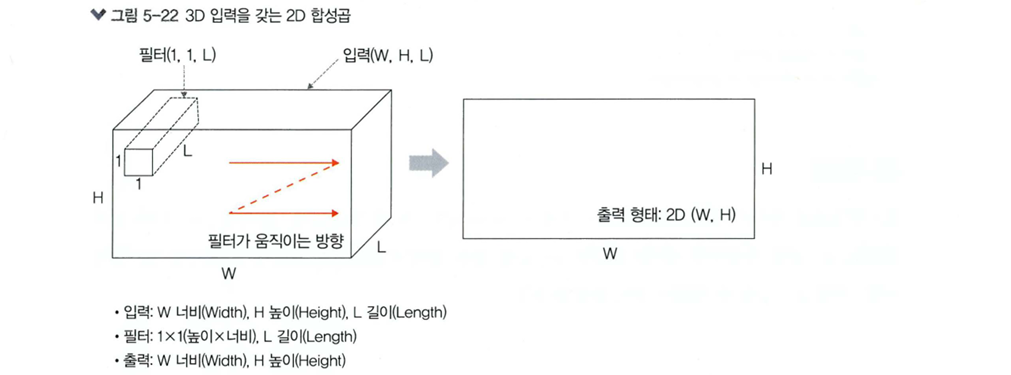

---

**1x1 합성곱**

- 입력(W, H, L)과 필터(1, 1, L)에 대한 출력은 (W, H)
- 1x1 합성곱에서 채널 수를 조정해서 연산량이 감소되는 효과가 있음.

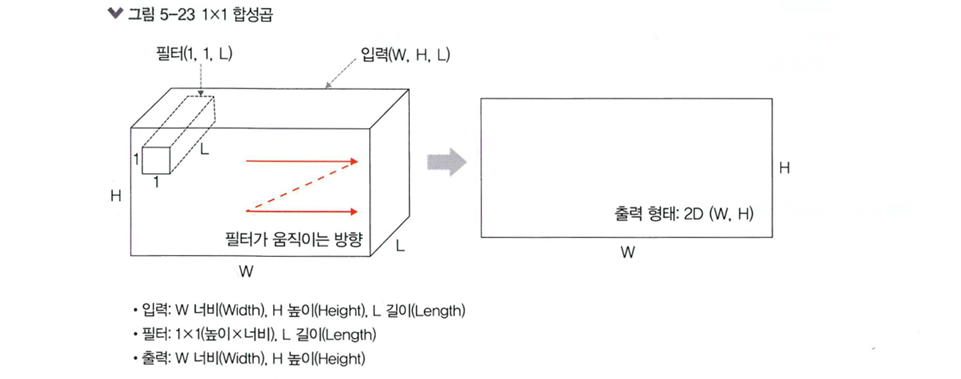